In [1]:
import pandas as pd

# Replace 'filename.csv' with the path to your CSV file
df = pd.read_csv('project.csv')

# Display the first 5 rows
print(df.head())


/var/folders/x5/rmz6246d09j8njb7w95f59lc0000gn/T/ipykernel_68010/3497244856.py:4: DtypeWarning: Columns (2,4,5,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('project.csv')


  metroplex state zip_code                                    hospital  \
0    Austin    TX    78717  Dell Childrens Medical Center North Campus   
1    Austin    TX    78717  Dell Childrens Medical Center North Campus   
2    Austin    TX    78717  Dell Childrens Medical Center North Campus   
3    Austin    TX    78717  Dell Childrens Medical Center North Campus   
4    Austin    TX    78717  Dell Childrens Medical Center North Campus   

  billing_code gross_charge  insurer_price  max_price  discounted_cash  \
0        99281       289.25            0.0     276.39           109.92   
1        99281       289.25            0.0     276.39           109.92   
2        99281       289.25            0.0     276.39           109.92   
3        99282        329.5            0.0     209.85           125.21   
4        99282        329.5            0.0     209.85           125.21   

       description  payer_name                      plan_name  \
0   VISIT ER LVL I     champva  1135_CHAMPVA 

In [13]:
import pandas as pd

# Price-related columns
price_cols = ['gross_charge', 'insurer_price', 'max_price', 'discounted_cash']

# Convert to numeric (safe if there are no symbols)
for col in price_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


Distribution of Charges

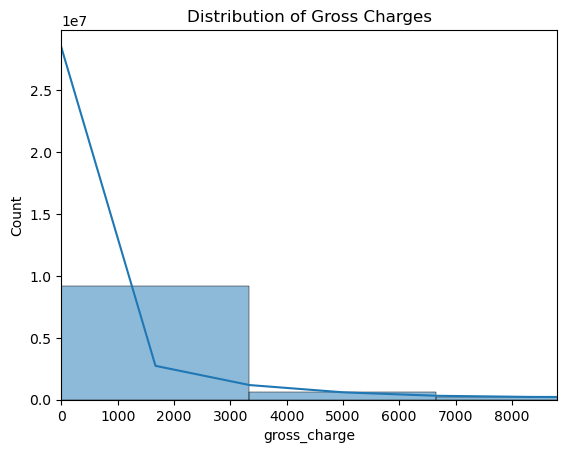

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['gross_charge'], bins=100, kde=True)
plt.title('Distribution of Gross Charges')
plt.xlim(0, df['gross_charge'].quantile(0.95))  # to remove outliers from view
plt.show()


Pricing Spread Analysis

<Axes: >

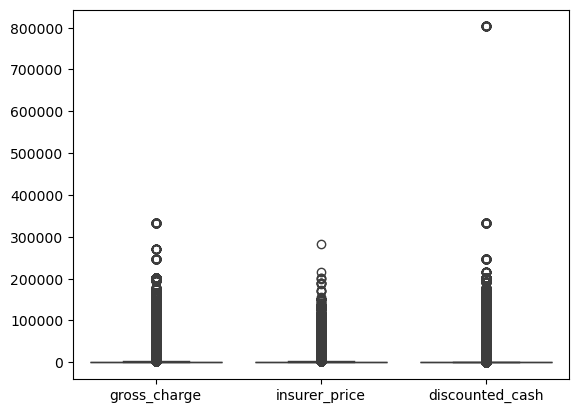

In [19]:
df['price_spread'] = df['gross_charge'] - df['discounted_cash']
sns.boxplot(data=df[['gross_charge', 'insurer_price', 'discounted_cash']])


Identify overpricing

In [31]:
df['overcharge_pct'] = ((df['gross_charge'] - df['discounted_cash']) / df['discounted_cash']) * 100
high_overcharge = df[df['overcharge_pct'] > 100]  # >100% markup


## Geographic Trends
Top states/zip codes by average price


In [33]:
state_avg = df.groupby('state')['gross_charge'].mean().sort_values(ascending=False)
print(state_avg.head())

zip_avg = df.groupby('zip_code')['gross_charge'].mean().sort_values(ascending=False)


state
New York        4544.822428
New Jersey      4257.982118
Pennsylvania    3906.580197
TX               585.980348
Name: gross_charge, dtype: float64


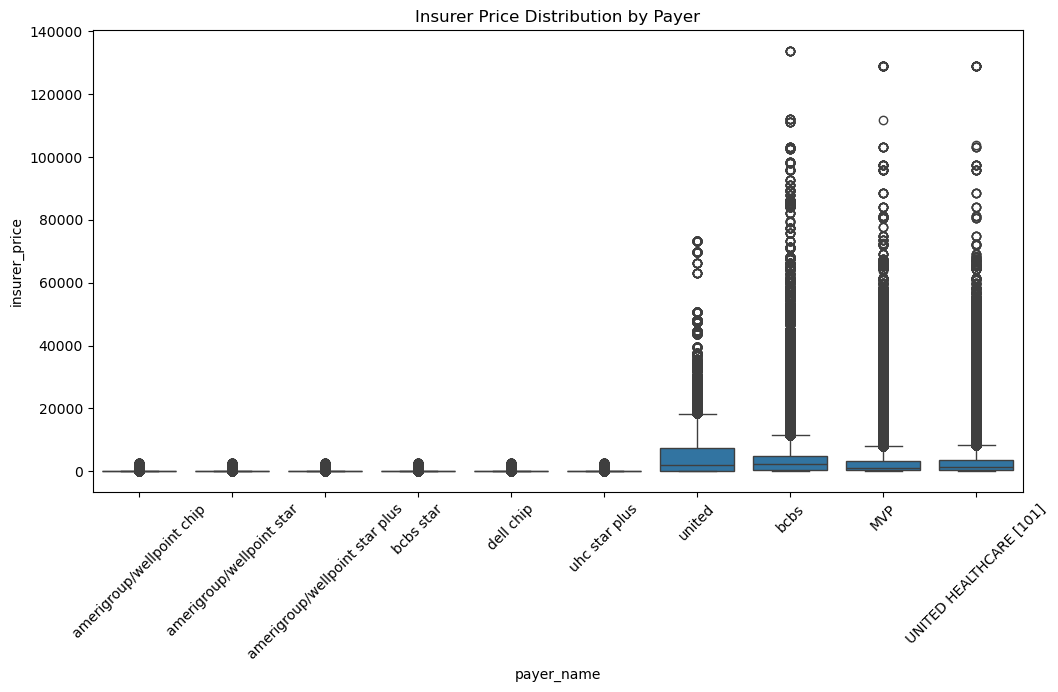

In [37]:
plt.figure(figsize=(12, 6))
top_payers = df['payer_name'].value_counts().nlargest(10).index
sns.boxplot(data=df[df['payer_name'].isin(top_payers)],
            x='payer_name', y='insurer_price')
plt.xticks(rotation=45)
plt.title('Insurer Price Distribution by Payer')
plt.show()


/var/folders/x5/rmz6246d09j8njb7w95f59lc0000gn/T/ipykernel_68010/325670084.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hospitals.values, y=top_hospitals.index, palette='viridis')


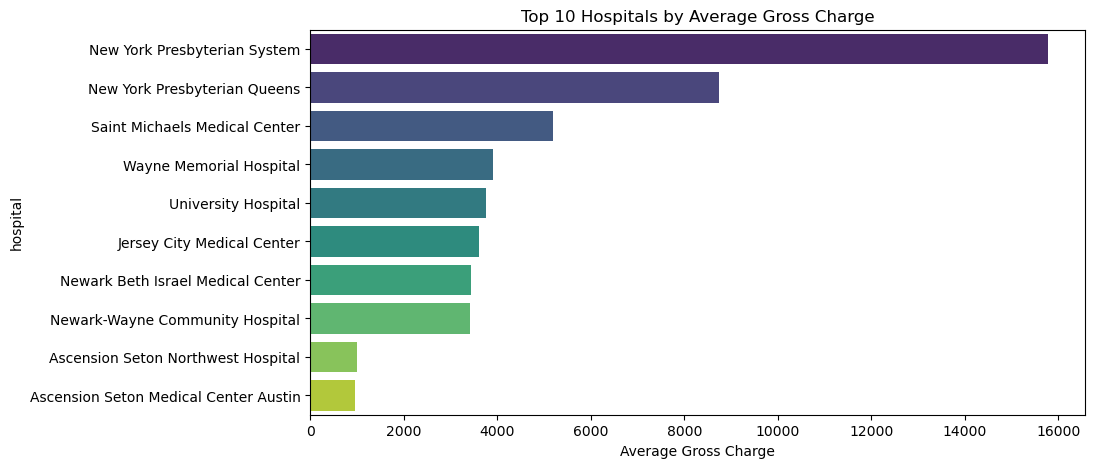

In [39]:
top_hospitals = df.groupby('hospital')['gross_charge'].mean().nlargest(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_hospitals.values, y=top_hospitals.index, palette='viridis')
plt.title('Top 10 Hospitals by Average Gross Charge')
plt.xlabel('Average Gross Charge')
plt.show()


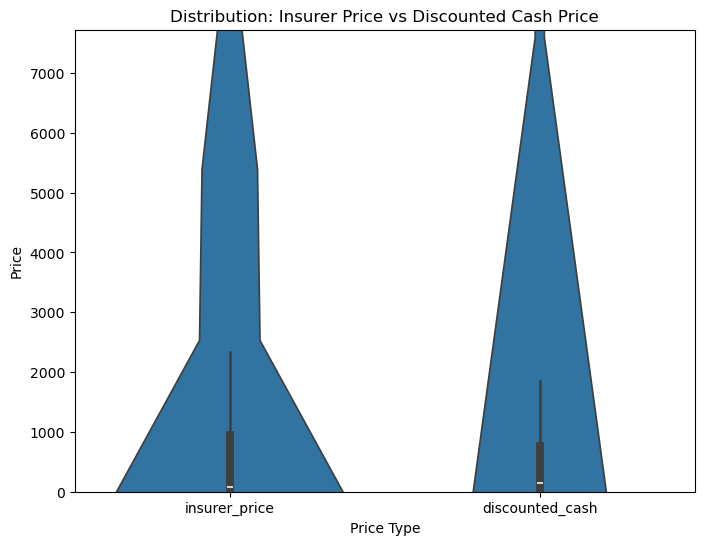

In [41]:
df_melted = df.melt(value_vars=['insurer_price', 'discounted_cash'], var_name='Price Type', value_name='Price')

plt.figure(figsize=(8, 6))
sns.violinplot(x='Price Type', y='Price', data=df_melted)
plt.title('Distribution: Insurer Price vs Discounted Cash Price')
plt.ylim(0, df_melted['Price'].quantile(0.95))
plt.show()


## Coefficient of Variation (Relative Price Variability)
Helps identify which price column is most inconsistent:
#### A higher CV means more volatility (e.g., insurer prices often vary more than discounted cash prices).

In [45]:
cv = df[price_cols].std() / df[price_cols].mean()
print("Coefficient of Variation:\n", cv)


Coefficient of Variation:
 gross_charge       3.242435
insurer_price      2.610413
max_price          2.273359
discounted_cash    4.097251
dtype: float64


## Outlier Detection (Z-score)
To find extreme overcharges:

In [49]:
from scipy.stats import zscore

df['gross_charge_z'] = zscore(df['gross_charge'].fillna(0))
outliers = df[df['gross_charge_z'] > 3]  # Customize the threshold if needed
print("Extreme outliers in gross charges:", len(outliers))


Extreme outliers in gross charges: 200291


## Price Ratios for Comparison
Useful to detect overpricing or negotiation gaps:
#### Closer to 1 = no discount

#### Closer to 0 = deep discount (cash or insurer negotiated price)

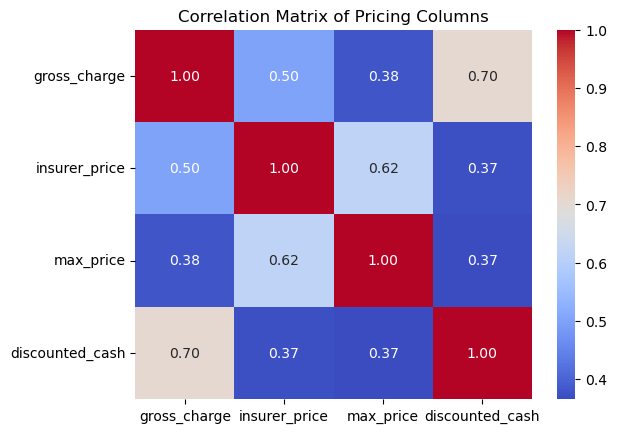

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[price_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Pricing Columns')
plt.show()


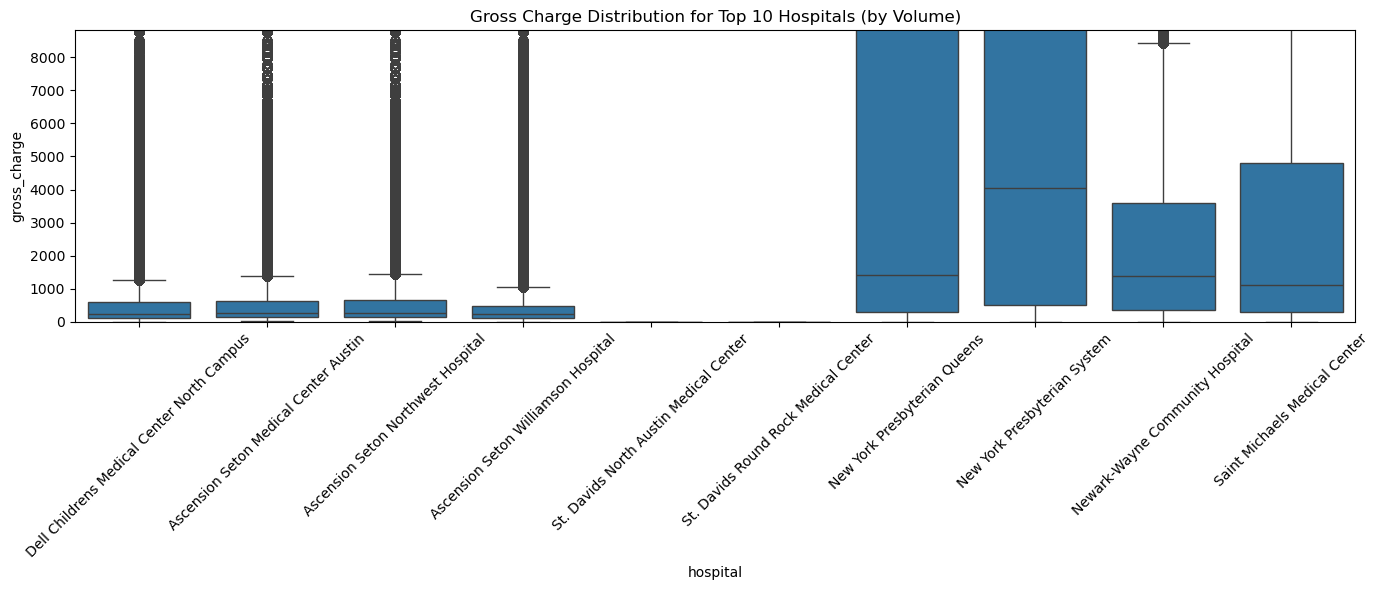

In [62]:
# Filter to top 10 hospitals by volume
top_hospitals = df['hospital'].value_counts().nlargest(10).index
filtered_df = df[df['hospital'].isin(top_hospitals)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='hospital', y='gross_charge', data=filtered_df)
plt.title("Gross Charge Distribution for Top 10 Hospitals (by Volume)")
plt.xticks(rotation=45)
plt.ylim(0, df['gross_charge'].quantile(0.95))  # Remove extreme outliers
plt.tight_layout()
plt.show()


## State-Level Price Fairness
Which states have the highest vs lowest average markup?

In [69]:
df['markup'] = df['gross_charge'] - df['discounted_cash']
state_markup = df.groupby('state')['markup'].mean().sort_values(ascending=False)

print(" States with highest average markup:")
print(state_markup.head())

print("\n States with lowest (or negative) markup:")
print(state_markup.tail())


 States with highest average markup:
state
New Jersey      3138.282932
New York        1049.943237
Pennsylvania     781.316108
TX              -185.569867
Name: markup, dtype: float64

 States with lowest (or negative) markup:
state
New Jersey      3138.282932
New York        1049.943237
Pennsylvania     781.316108
TX              -185.569867
Name: markup, dtype: float64


## Top Overpriced Procedures
Find which procedures have the highest average gross-to-cash price difference.

In [74]:
procedure_markup = df.groupby('description').agg(
    count=('gross_charge', 'count'),
    avg_gross=('gross_charge', 'mean'),
    avg_cash=('discounted_cash', 'mean')
)
procedure_markup['diff'] = procedure_markup['avg_gross'] - procedure_markup['avg_cash']
top_diff = procedure_markup[procedure_markup['count'] > 10].sort_values(by='diff', ascending=False)

print("📌 Top 5 overpriced procedures (by avg gross - cash):")
print(top_diff.head())


📌 Top 5 overpriced procedures (by avg gross - cash):
                                             count  avg_gross  avg_cash  \
description                                                               
HC TCAT IMP WRLS PULM ARTRY SENSR               44   146704.0  41244.00   
HC RMVL & RPLCMT DFB GEN 2 LEAD                 25   122510.0  31001.72   
HC RMVL& REPLC PULSE GEN 1 LEAD                 25   122510.0  31001.72   
HC INSERT/REMOVE PERMENET SUBQ IMPLANT DEFI     25   123433.0  43269.70   
HC INSERT PULSE GEN,SNGLDUAL                    44   110000.0  33449.00   

                                                  diff  
description                                             
HC TCAT IMP WRLS PULM ARTRY SENSR            105460.00  
HC RMVL & RPLCMT DFB GEN 2 LEAD               91508.28  
HC RMVL& REPLC PULSE GEN 1 LEAD               91508.28  
HC INSERT/REMOVE PERMENET SUBQ IMPLANT DEFI   80163.30  
HC INSERT PULSE GEN,SNGLDUAL                  76551.00  


## Most Reasonable Hospitals (Fair Cash Pricing)

In [85]:
df['cash_vs_insurer_diff'] = abs(df['discounted_cash'] - df['insurer_price'])
fair_hospitals = df.groupby('hospital')['cash_vs_insurer_diff'].mean().sort_values()

print("Hospitals with least variation between cash & insurer price:")
print(fair_hospitals.head())


Hospitals with least variation between cash & insurer price:
hospital
Ascension Seton Shoal Creek                    78.600000
Ascension Seton Williamson Hospital           208.597018
Dell Childrens Medical Center North Campus    246.057439
Saint Josephs Medical Center                  246.495095
Ascension Seton Medical Center Austin         267.992106
Name: cash_vs_insurer_diff, dtype: float64


## What This Tells Us:
Lower Cash-Insurer Price Difference: These hospitals have a relatively small gap between the prices they charge insurers and the prices they offer for cash payments. This is generally a good sign for consumers, as it indicates more fair and transparent pricing.

Less Price Discrepancy: Patients who choose to pay out-of-pocket at these hospitals are not significantly penalized compared to those covered by insurance. This makes it easier for patients to plan their healthcare expenses, especially for those who prefer not to deal with insurance.

Potential for Price Transparency Best Practices: These hospitals could be leading examples of pricing practices that minimize discrepancies. Other hospitals in the region might look to them as models for how to offer consistent pricing for both insured and cash-paying patients.

## Regional Pricing Trends (State-Level Analysis)

In [94]:
state_avg = df.groupby('state')['gross_charge'].mean()
state_variance = df.groupby('state')['gross_charge'].std()

# Display results
state_summary = pd.DataFrame({'state_avg': state_avg, 'state_variance': state_variance})
print(state_summary.sort_values('state_avg', ascending=False).head(10))  # Top states by avg price


                state_avg  state_variance
state                                    
New York      4544.822428     9571.846030
New Jersey    4257.982118     8694.244167
Pennsylvania  3906.580197    11797.430014
TX             585.980348     2665.306473


## Average Gross Charges by State:
New York ($4544.82) and New Jersey ($4257.98) have the highest average gross charges, suggesting that healthcare services in these states are significantly more expensive than in Texas (TX, $585.98).

The Texas value being much lower means healthcare costs in Texas may be more affordable, possibly due to local competition, state regulations, or lower cost of living.

## Key Conclusions:
New York and New Jersey have high average prices, but this comes with price variability that could be a sign of inequities in the pricing system (e.g., patients being charged wildly different amounts for similar procedures).

Texas offers relatively low and more consistent prices, making it potentially a more affordable market for consumers.